In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from lmfit.models import GaussianModel
import matplotlib as m

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [5]:
header = "D:/K_sunada/result/CDY153/"
vac = "/2024-01-04/2024-01-04T181314_7dab30b4-80_JPA_vac_squeeze"
dd = datadict_from_hdf5(header + vac +"/data")

In [4]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

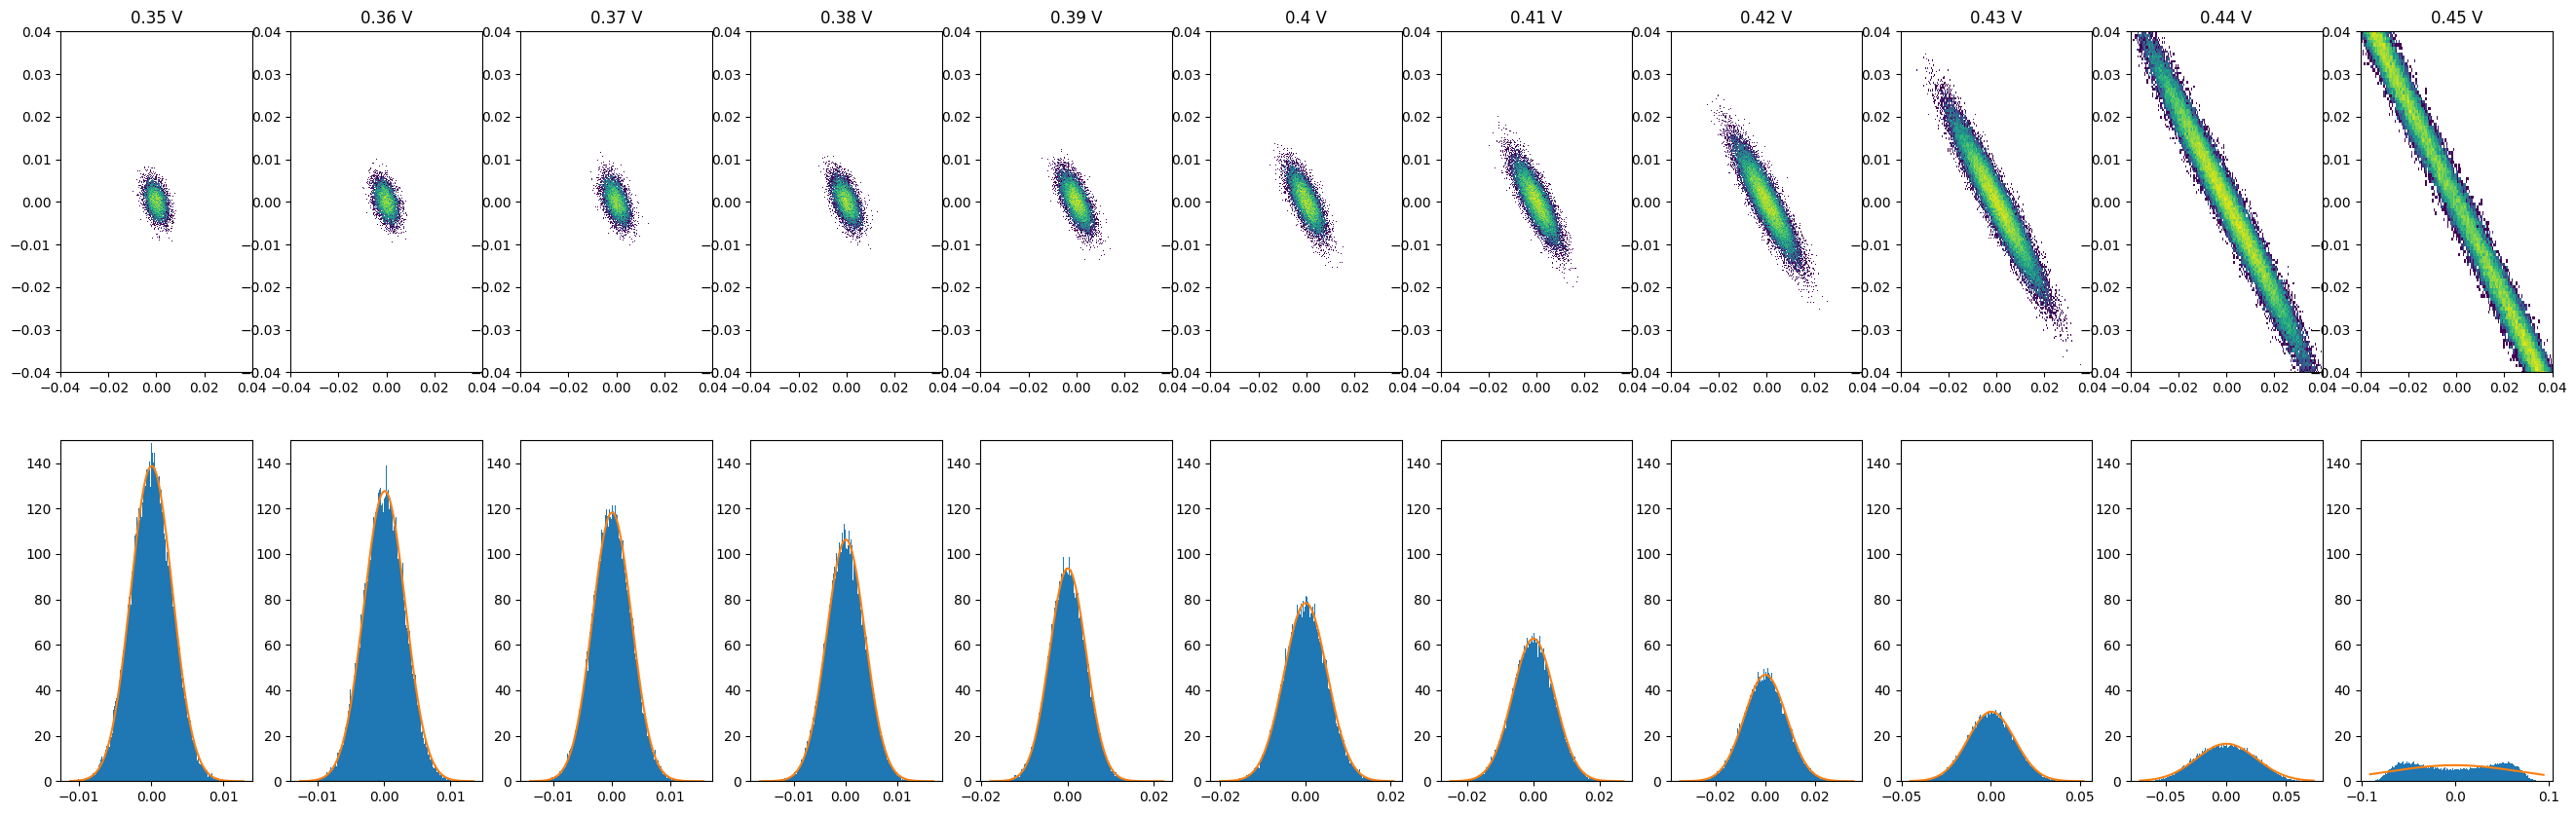

In [6]:
pump_amplitude = dd["pump_amplitude"]["values"]
s11 = dd["s11"]["values"]
fig = plt.figure(figsize=(3 * len(pump_amplitude), 10))
for i in range(len(pump_amplitude)):
    s_11 = s11[i]
    s11_pca = PCA_transform(s_11.real, s_11.imag)[0]
    
    ax = fig.add_subplot(2, len(pump_amplitude), i + 1)
    ax.hist2d(s_11.real, s_11.imag, bins=200, cmin=1, norm=m.colors.LogNorm())
    ax.set_title(f"{np.round(pump_amplitude[i], decimals=3)} V")
    ax.set_xlim(-0.04, 0.04)
    ax.set_ylim(-0.04, 0.04)

    hist, bins = np.histogram(s11_pca, bins=200, density=True)
    model = GaussianModel()
    params = model.guess(hist, x = bins[1:])
    result = model.fit(hist, params, x = bins[1:])
    ax2 = fig.add_subplot(2, len(pump_amplitude), i + 1 + len(pump_amplitude))
    ax2.hist(s11_pca, bins=200, density=True)
    ax2.set_ylim(0, 150)
    ax2.plot(bins[1:], result.best_fit, label="gaussian fit")
# plt.legend()
plt.show()

    

In [7]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

phase optimization

In [79]:
data = "/2024-01-05/2024-01-05T173118_cc8b219a-81_JPA_phase_optimization_for_ge"  #10dB
dd = datadict_from_hdf5(header + data +"/data")
dd

distance: (41,)
  ⌙ phase (rad): (41,)

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
       1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
       1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  ])

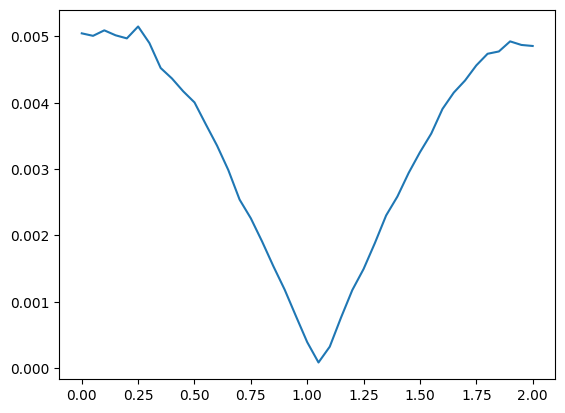

In [81]:
x = dd["phase"]["values"]
y = dd["distance"]["values"]
y_pca = PCA_transform(y.real, y.imag)[0]
plt.plot(x, np.abs(y))
x

readout fidelity

readout fidelity for g: 0.9881515313769382
readout fidelity for e: 0.965904179022952


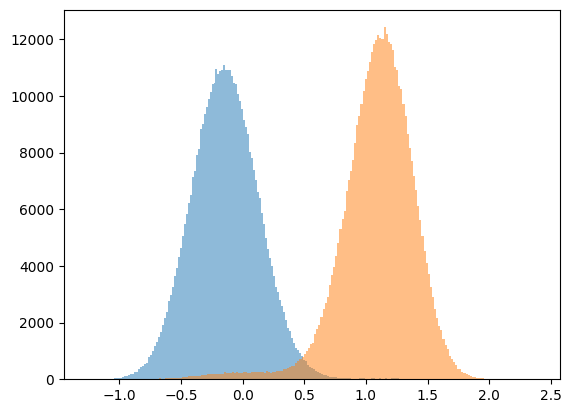

In [86]:
data = "/2024-01-07/2024-01-07T145509_50880c36-83_readout_fidelity" #0.7
dd =datadict_from_hdf5(header + data +"/data")
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()


plt.hist(signal_g, bins=200, alpha=0.5, log=0)
plt.hist(signal_e, bins=200, alpha=0.5)
print(f"readout fidelity for g: {1- len([el for el in signal_g if el>0.5])/len(signal_g)}")
print(f"readout fidelity for e: {1- len([el for el in signal_e if el<0.5])/len(signal_e)}")

g population: 0.49977968525230354
e population: 0.5002203147476965


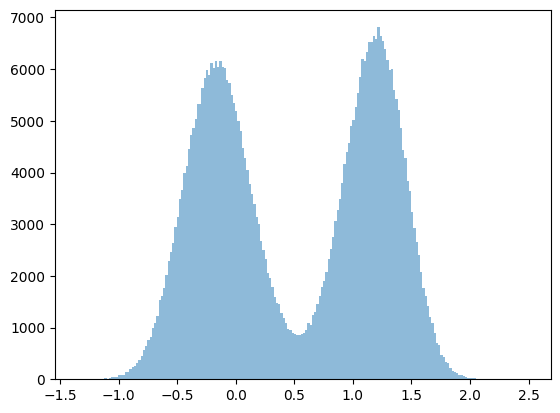

In [91]:
# half pi (z)
data = "/2024-01-07/2024-01-07T160410_f5090de8-84_tomography_test" #0.7
dd =datadict_from_hdf5(header + data +"/data")
signal_ge = dd["signal_ge"]["values"].ravel()

plt.hist(signal_ge, bins=200, alpha=0.5)
print(f"g population: {1- len([el for el in signal_ge if el>0.5])/len(signal_ge)}")
print(f"e population: {1- len([el for el in signal_ge if el<0.5])/len(signal_ge)}")

g population: 0.05642099580292925
e population: 0.9435790041970707


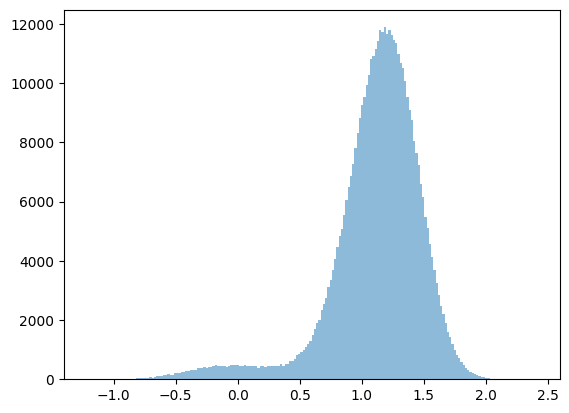

In [93]:
# half pi (phase; 0)
data = "/2024-01-07/2024-01-07T162533_f1f16b68-84_tomography_test" 
dd =datadict_from_hdf5(header + data +"/data")
signal_ge = dd["signal_ge"]["values"].ravel()

plt.hist(signal_ge, bins=200, alpha=0.5)
print(f"i population: {1- len([el for el in signal_ge if el>0.5])/len(signal_ge)}")
print(f"-i population: {1- len([el for el in signal_ge if el<0.5])/len(signal_ge)}")

i population: 0.9171367778303677
-i population: 0.08286322216963227


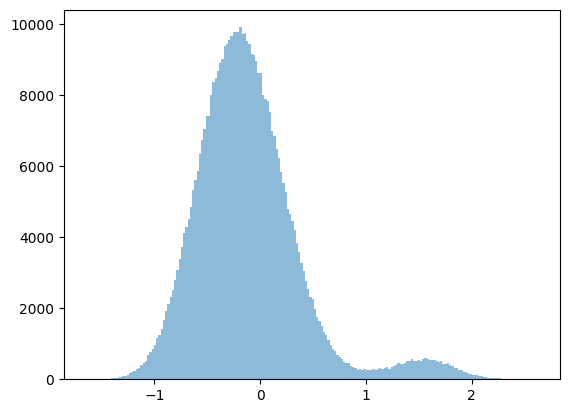

In [99]:
# half pi (phase; pi/2)
data = "/2024-01-07/2024-01-07T164538_c028904e-85_tomography_test" 
dd =datadict_from_hdf5(header + data +"/data")
signal_ge = dd["signal_ge"]["values"].ravel()

plt.hist(signal_ge, bins=200, alpha=0.5)
print(f"i population: {1- len([el for el in signal_ge if el>0.5])/len(signal_ge)}")
print(f"-i population: {1- len([el for el in signal_ge if el<0.5])/len(signal_ge)}")

1 population: 0.6569276013192393
-1 population: 0.34307239868076067
i population: 0.9489275311897393
-i population: 0.05107246881026073
g population: 0.5064096565921212
e population: 0.4935903434078788


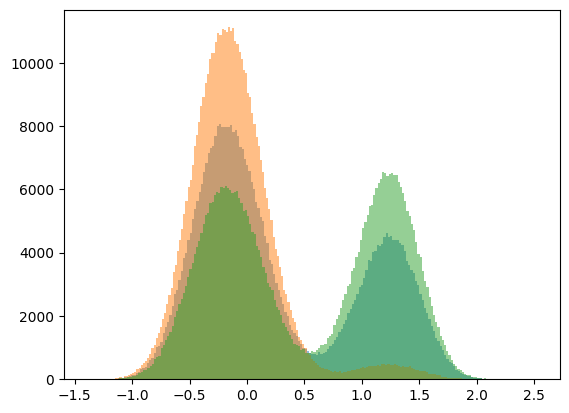

In [102]:
# half pi tomography
data = "/2024-01-07/2024-01-07T170944_1e08def6-85_tomography_test" 
dd =datadict_from_hdf5(header + data +"/data")
signal_x = dd["signal_x"]["values"].ravel()
signal_y = dd["signal_y"]["values"].ravel()
signal_z = dd["signal_z"]["values"].ravel()

plt.hist(signal_x, bins=200, alpha=0.5)
plt.hist(signal_y, bins=200, alpha=0.5)
plt.hist(signal_z, bins=200, alpha=0.5)
print(f"1 population: {1- len([el for el in signal_x if el>0.5])/len(signal_x)}")
print(f"-1 population: {1- len([el for el in signal_x if el<0.5])/len(signal_x)}")
print(f"i population: {1- len([el for el in signal_y if el>0.5])/len(signal_y)}")
print(f"-i population: {1- len([el for el in signal_y if el<0.5])/len(signal_y)}")
print(f"g population: {1- len([el for el in signal_z if el>0.5])/len(signal_z)}")
print(f"e population: {1- len([el for el in signal_z if el<0.5])/len(signal_z)}")

1 population: 0.3618806370622213
-1 population: 0.6381193629377787
i population: 0.9497488657027346
-i population: 0.050251134297265354
g population: 0.501125100992003
e population: 0.498874899007997


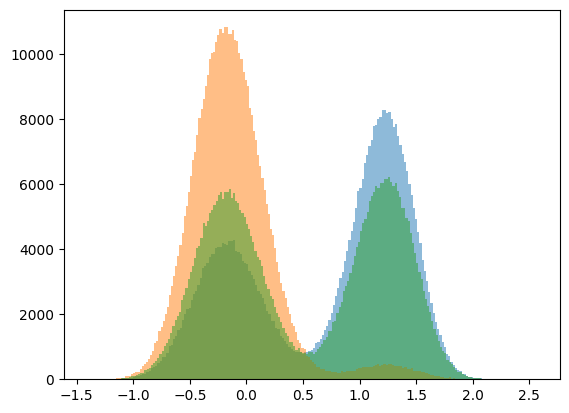

In [103]:
# half pi tomography (x: pi)
data = "/2024-01-07/2024-01-07T171553_f9ea88cd-85_tomography_test" 
dd =datadict_from_hdf5(header + data +"/data")
signal_x = dd["signal_x"]["values"].ravel()
signal_y = dd["signal_y"]["values"].ravel()
signal_z = dd["signal_z"]["values"].ravel()

plt.hist(signal_x, bins=200, alpha=0.5)
plt.hist(signal_y, bins=200, alpha=0.5)
plt.hist(signal_z, bins=200, alpha=0.5)
print(f"1 population: {1- len([el for el in signal_x if el>0.5])/len(signal_x)}")
print(f"-1 population: {1- len([el for el in signal_x if el<0.5])/len(signal_x)}")
print(f"i population: {1- len([el for el in signal_y if el>0.5])/len(signal_y)}")
print(f"-i population: {1- len([el for el in signal_y if el<0.5])/len(signal_y)}")
print(f"g population: {1- len([el for el in signal_z if el>0.5])/len(signal_z)}")
print(f"e population: {1- len([el for el in signal_z if el<0.5])/len(signal_z)}")

In [143]:
data = "/2024-01-07/2024-01-07T171553_f9ea88cd-85_tomography_test" 
dd =datadict_from_hdf5(header + data +"/data")
signal_x = dd["signal_x"]["values"]
signal_x.shape

(1, 446487)

ph absorption tomography

In [417]:
def tomography(data, title):
    signal_x_0 = dd["signal_x_0"]["values"].ravel()
    signal_y_0 = dd["signal_y_0"]["values"].ravel()
    signal_z_0 = dd["signal_z_0"]["values"].ravel()
    signal_x_pi_2 = dd["signal_x_pi_2"]["values"].ravel()
    signal_y_pi_2 = dd["signal_y_pi_2"]["values"].ravel()
    signal_z_pi_2 = dd["signal_z_pi_2"]["values"].ravel()
    signal_x_pi = dd["signal_x_pi"]["values"].ravel()
    signal_y_pi = dd["signal_y_pi"]["values"].ravel()
    signal_z_pi = dd["signal_z_pi"]["values"].ravel()
    signal_x_pi_2_mi = dd["signal_x_pi_2_mi"]["values"].ravel()
    signal_y_pi_2_mi = dd["signal_y_pi_2_mi"]["values"].ravel()
    signal_z_pi_2_mi = dd["signal_z_pi_2_mi"]["values"].ravel()
    
    Pop1_0 = 1- len([el for el in signal_x_0 if el>0.5])/len(signal_x_0)
    Pop_1_0 = 1- len([el for el in signal_x_0 if el<0.5])/len(signal_x_0)
    Popi_0 = 1- len([el for el in signal_y_0 if el>0.5])/len(signal_y_0)
    Pop_i_0 = 1- len([el for el in signal_y_0 if el<0.5])/len(signal_y_0)
    Popg_0 = 1- len([el for el in signal_z_0 if el>0.5])/len(signal_z_0)
    Pope_0 = 1- len([el for el in signal_z_0 if el<0.5])/len(signal_z_0)
    Pop1_pi_2 = 1- len([el for el in signal_x_pi_2 if el>0.5])/len(signal_x_pi_2)
    Pop_1_pi_2 = 1- len([el for el in signal_x_pi_2 if el<0.5])/len(signal_x_pi_2)
    Popi_pi_2 = 1- len([el for el in signal_y_pi_2 if el>0.5])/len(signal_y_pi_2)
    Pop_i_pi_2 = 1- len([el for el in signal_y_pi_2 if el<0.5])/len(signal_y_pi_2)
    Popg_pi_2 = 1- len([el for el in signal_z_pi_2 if el>0.5])/len(signal_z_pi_2)
    Pope_pi_2 = 1- len([el for el in signal_z_pi_2 if el<0.5])/len(signal_z_pi_2)
    Pop1_pi = 1- len([el for el in signal_x_pi if el>0.5])/len(signal_x_pi)
    Pop_1_pi = 1- len([el for el in signal_x_pi if el<0.5])/len(signal_x_pi)
    Popi_pi = 1- len([el for el in signal_y_pi if el>0.5])/len(signal_y_pi)
    Pop_i_pi = 1- len([el for el in signal_y_pi if el<0.5])/len(signal_y_pi)
    Popg_pi = 1- len([el for el in signal_z_pi if el>0.5])/len(signal_z_pi)
    Pope_pi = 1- len([el for el in signal_z_pi if el<0.5])/len(signal_z_pi)
    Pop1_pi_2_mi = 1- len([el for el in signal_x_pi_2_mi if el>0.5])/len(signal_x_pi_2)
    Pop_1_pi_2_mi = 1- len([el for el in signal_x_pi_2_mi if el<0.5])/len(signal_x_pi_2)
    Popi_pi_2_mi = 1- len([el for el in signal_y_pi_2_mi if el>0.5])/len(signal_y_pi_2)
    Pop_i_pi_2_mi = 1- len([el for el in signal_y_pi_2_mi if el<0.5])/len(signal_y_pi_2)
    Popg_pi_2_mi = 1- len([el for el in signal_z_pi_2_mi if el>0.5])/len(signal_z_pi_2)
    Pope_pi_2_mi = 1- len([el for el in signal_z_pi_2_mi if el<0.5])/len(signal_z_pi_2)
    
    fig,ax = plt.subplots(1,4, figsize=(20,7))
    plt.rcParams["font.size"] = 20
    plt.suptitle(title)
    ax[0].hist(signal_x_0, bins=200, alpha=0.5)
    ax[0].hist(signal_y_0, bins=200, alpha=0.5)
    ax[0].hist(signal_z_0, bins=200, alpha=0.5)
    ax[0].set_title("$\phi$ = 0")
    textstr0 = '\n'.join((r"$+:{}$".format(np.round(Pop1_0, 3)),
                        r"$-:{}$".format(np.round(Pop_1_0, 3)),
                        r"$ i:{}$".format(np.round(Popi_0, 3)),
                        r"$-i:{}$".format(np.round(Pop_i_0, 3)),
                        r"$ g:{}$".format(np.round(Popg_0, 3)),
                        r"$ e:{}$".format(np.round(Pope_0, 3)),))
    props0 = dict( facecolor='wheat', alpha=0.5)
    ax[0].text(0.72, 0.97, textstr0, transform=ax[0].transAxes,
            fontsize=14,verticalalignment='top', bbox=props0)
    ax[1].hist(signal_x_pi_2, bins=200, alpha=0.5)
    ax[1].hist(signal_y_pi_2, bins=200, alpha=0.5)
    ax[1].hist(signal_z_pi_2, bins=200, alpha=0.5)
    ax[1].set_title('$\phi$ = $\pi$/2')
    textstr1 = '\n'.join((r"$ +:{}$".format(np.round(Pop1_pi_2, 3)),
                        r"$-:{}$".format(np.round(Pop_1_pi_2, 3)),
                        r"$ i:{}$".format(np.round(Popi_pi_2, 3)),
                        r"$-i:{}$".format(np.round(Pop_i_pi_2, 3)),
                        r"$ g:{}$".format(np.round(Popg_pi_2, 3)),
                        r"$ e:{}$".format(np.round(Pope_pi_2, 3)),))
    props1 = dict( facecolor='wheat', alpha=0.5)
    ax[1].text(0.72, 0.97, textstr1, transform=ax[1].transAxes,
            fontsize=14,verticalalignment='top', bbox=props1)
    ax[2].hist(signal_x_pi, bins=200, alpha=0.5)
    ax[2].hist(signal_y_pi, bins=200, alpha=0.5)
    ax[2].hist(signal_z_pi, bins=200, alpha=0.5)
    ax[2].set_title('$\phi$ = $\pi$')
    textstr2 = '\n'.join((r"$ +:{}$".format(np.round(Pop1_pi, 3)),
                        r"$-:{}$".format(np.round(Pop_1_pi, 3)),
                        r"$ i:{}$".format(np.round(Popi_pi, 3)),
                        r"$-i:{}$".format(np.round(Pop_i_pi, 3)),
                        r"$ g:{}$".format(np.round(Popg_pi, 3)),
                        r"$ e:{}$".format(np.round(Pope_pi, 3)),))
    props2 = dict( facecolor='wheat', alpha=0.5)
    ax[2].text(0.72, 0.97, textstr2, transform=ax[2].transAxes,
            fontsize=14,verticalalignment='top', bbox=props2)
    ax[3].hist(signal_x_pi_2_mi, bins=200, alpha=0.5)
    ax[3].hist(signal_y_pi_2_mi, bins=200, alpha=0.5)
    ax[3].hist(signal_z_pi_2_mi, bins=200, alpha=0.5)
    ax[3].set_title('$\phi$ = $-\pi/2$')
    textstr3 = '\n'.join((r"$ +:{}$".format(np.round(Pop1_pi_2_mi, 3)),
                        r"$-:{}$".format(np.round(Pop_1_pi_2_mi, 3)),
                        r"$ i:{}$".format(np.round(Popi_pi_2_mi, 3)),
                        r"$-i:{}$".format(np.round(Pop_i_pi_2_mi, 3)),
                        r"$ g:{}$".format(np.round(Popg_pi_2_mi, 3)),
                        r"$ e:{}$".format(np.round(Pope_pi_2_mi, 3)),))
    props3 = dict( facecolor='wheat', alpha=0.5)
    ax[3].text(0.72, 0.97, textstr3, transform=ax[3].transAxes,
            fontsize=14,verticalalignment='top', bbox=props2)
    plt.tight_layout()
    

In [418]:
def rho_plot(rho):
    x_labels = [r'$|0\rangle$', r'$|1\rangle$']
    y_labels = [r'$|0\rangle$', r'$|1\rangle$']

    fig = plt.figure(figsize=(5,3.5))
    plt.rcParams['figure.figsize'] = [3, 2]
    fig.subplots_adjust(left=-0.2)
    ax = fig.add_subplot(111, projection='3d')

    bar_width = 0.5

    colormap = plt.get_cmap('hsv')


    for i in range(2):
        for j in range(2):
            height = np.abs(rho[i,j])
            x = i
            y = j
            z = 0
            color = (np.angle(rho[i,j]) + np.pi) / (2 * np.pi)
            # print(np.angle(rho[i,j]))
            ax.bar3d(x, y, z, bar_width, bar_width, height, color=colormap(color), alpha=1)

    ax.set_xlim(-0.5, 2)
    ax.set_ylim(-0.5, 2)
    ax.set_zlim(0, 1)

    ax.set_xticks(np.arange(2) + 0.5 * bar_width)
    ax.set_yticks(np.arange(2) + 0.5 * bar_width )
    ax.set_zticks([0, 0.5, 1.0])
    ax.tick_params(axis='z', labelsize=13)

    ax.set_xticklabels(x_labels, fontsize=12)
    ax.set_yticklabels(y_labels, fontsize=12)

    ax.set_zlabel('Absolute value', labelpad=5, rotation=-90, fontsize=13)
    ax.zaxis.set_rotate_label(False)

    m = plt.cm.ScalarMappable(cmap=colormap)
    m.set_array(np.array([-1, 1]))
    cbar = plt.colorbar(m, shrink=0.7, pad=0.2, ax=ax)  # shrink‚Å'å‚«‚³‚ð¬‚³‚‚µApad‚ÅˆÊ'u‚ð'²®‚·‚é
    # cbar.ax.set_position([0.1, 0, 0.02, 1])
    cbar.set_ticks([-1, -1/2, 0, 1/2, 1])
    cbar.set_ticklabels(['$-\pi$', '$-\pi/2$', '0', '$\pi/2$', '$\pi$'], fontsize=13)
    cbar.set_label('Phase', labelpad=-50, rotation=-90, fontsize=13)

    cbar.ax.yaxis.set_ticks_position('left')
    cbar.ax.yaxis.set_label_position('left')

In [420]:
def target_rho(alpha, phi):
    return np.array([[1/(1+alpha*2), alpha*np.exp(1j*phi)/(1+alpha*2)], [alpha*np.exp(-1j*phi)/(1+alpha*2), alpha**2/(1+alpha*2)]])

In [ ]:
def tomography_rho(data, alpha):
    signal_x_0 = dd["signal_x_0"]["values"].ravel()
    signal_y_0 = dd["signal_y_0"]["values"].ravel()
    signal_z_0 = dd["signal_z_0"]["values"].ravel()
    signal_x_pi_2 = dd["signal_x_pi_2"]["values"].ravel()
    signal_y_pi_2 = dd["signal_y_pi_2"]["values"].ravel()
    signal_z_pi_2 = dd["signal_z_pi_2"]["values"].ravel()
    signal_x_pi = dd["signal_x_pi"]["values"].ravel()
    signal_y_pi = dd["signal_y_pi"]["values"].ravel()
    signal_z_pi = dd["signal_z_pi"]["values"].ravel()
    signal_x_pi_2_mi = dd["signal_x_pi_2_mi"]["values"].ravel()
    signal_y_pi_2_mi = dd["signal_y_pi_2_mi"]["values"].ravel()
    signal_z_pi_2_mi = dd["signal_z_pi_2_mi"]["values"].ravel()
    
    Pop1_0 = 1- len([el for el in signal_x_0 if el>0.5])/len(signal_x_0)
    Pop_1_0 = 1- len([el for el in signal_x_0 if el<0.5])/len(signal_x_0)
    Popi_0 = 1- len([el for el in signal_y_0 if el>0.5])/len(signal_y_0)
    Pop_i_0 = 1- len([el for el in signal_y_0 if el<0.5])/len(signal_y_0)
    Popg_0 = 1- len([el for el in signal_z_0 if el>0.5])/len(signal_z_0)
    Pope_0 = 1- len([el for el in signal_z_0 if el<0.5])/len(signal_z_0)
    
    Pop1_pi_2 = 1- len([el for el in signal_x_pi_2 if el>0.5])/len(signal_x_pi_2)
    Pop_1_pi_2 = 1- len([el for el in signal_x_pi_2 if el<0.5])/len(signal_x_pi_2)
    Popi_pi_2 = 1- len([el for el in signal_y_pi_2 if el>0.5])/len(signal_y_pi_2)
    Pop_i_pi_2 = 1- len([el for el in signal_y_pi_2 if el<0.5])/len(signal_y_pi_2)
    Popg_pi_2 = 1- len([el for el in signal_z_pi_2 if el>0.5])/len(signal_z_pi_2)
    Pope_pi_2 = 1- len([el for el in signal_z_pi_2 if el<0.5])/len(signal_z_pi_2)

    Pop1_pi = 1- len([el for el in signal_x_pi if el>0.5])/len(signal_x_pi)
    Pop_1_pi = 1- len([el for el in signal_x_pi if el<0.5])/len(signal_x_pi)
    Popi_pi = 1- len([el for el in signal_y_pi if el>0.5])/len(signal_y_pi)
    Pop_i_pi = 1- len([el for el in signal_y_pi if el<0.5])/len(signal_y_pi)
    Popg_pi = 1- len([el for el in signal_z_pi if el>0.5])/len(signal_z_pi)
    Pope_pi = 1- len([el for el in signal_z_pi if el<0.5])/len(signal_z_pi)

    Pop1_pi_2_mi = 1- len([el for el in signal_x_pi_2_mi if el>0.5])/len(signal_x_pi_2)
    Pop_1_pi_2_mi = 1- len([el for el in signal_x_pi_2_mi if el<0.5])/len(signal_x_pi_2)
    Popi_pi_2_mi = 1- len([el for el in signal_y_pi_2_mi if el>0.5])/len(signal_y_pi_2)
    Pop_i_pi_2_mi = 1- len([el for el in signal_y_pi_2_mi if el<0.5])/len(signal_y_pi_2)
    Popg_pi_2_mi = 1- len([el for el in signal_z_pi_2_mi if el>0.5])/len(signal_z_pi_2)
    Pope_pi_2_mi = 1- len([el for el in signal_z_pi_2_mi if el<0.5])/len(signal_z_pi_2)
    
    
    return rho_0, rho_pi_2, rho_pi, rho_pi_2_mi
    

In [ ]:
def tomography_rho_plot(rho_0, rho_pi_2, rho_pi, rho_pi_2_mi, alpha):
    
    target_rho(alpha, 0)

In [ ]:
data = ""
alpha = 0.03
rho = tomography_rho(data, alpha)
tomography_rho_plot(rho[0], rho[1],rho[2],rho[3])

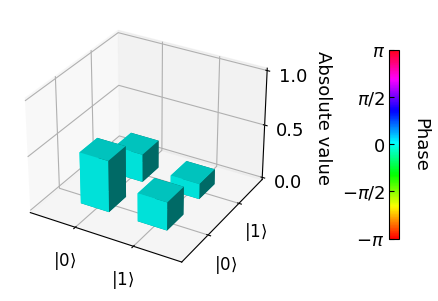

In [419]:
alpha = 0.3**0.5
phi = 0
target_rho = np.array([[1/(1+alpha*2), alpha*np.exp(1j*phi)/(1+alpha*2)], [alpha*np.exp(-1j*phi)/(1+alpha*2), alpha**2/(1+alpha*2)]])

rho_plot(target_rho)

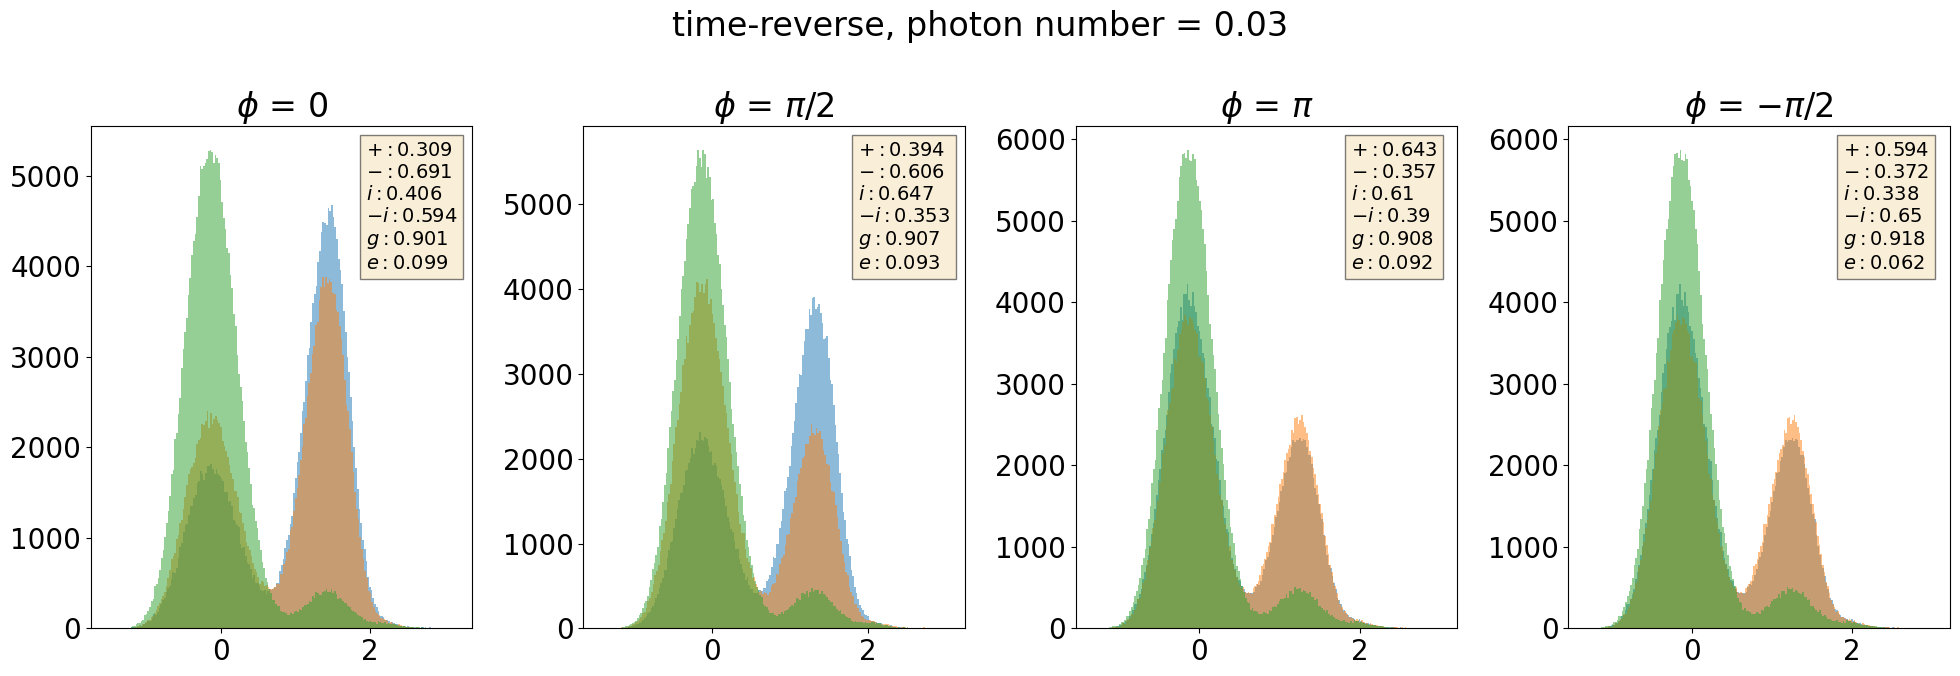

In [270]:
## tr, ph_num 0.03
data = "/2024-01-08/2024-01-08T160726_947a047c-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data, "time-reverse, photon number = 0.03")

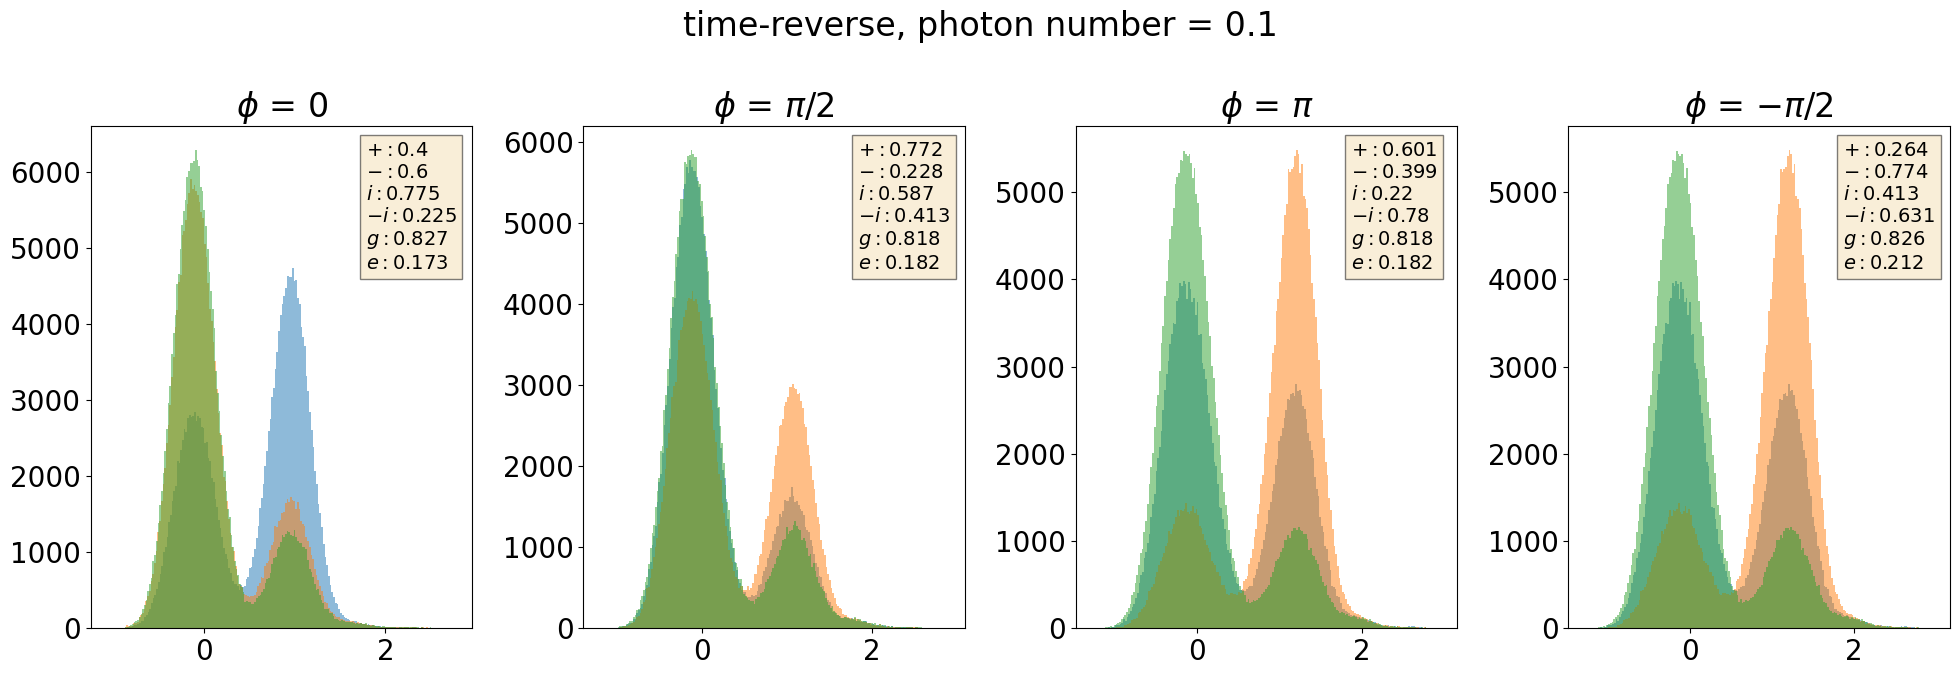

In [271]:
## tr, ph_num = 0.1
data = "/2024-01-08/2024-01-08T160125_bd35247b-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data, "time-reverse, photon number = 0.1")

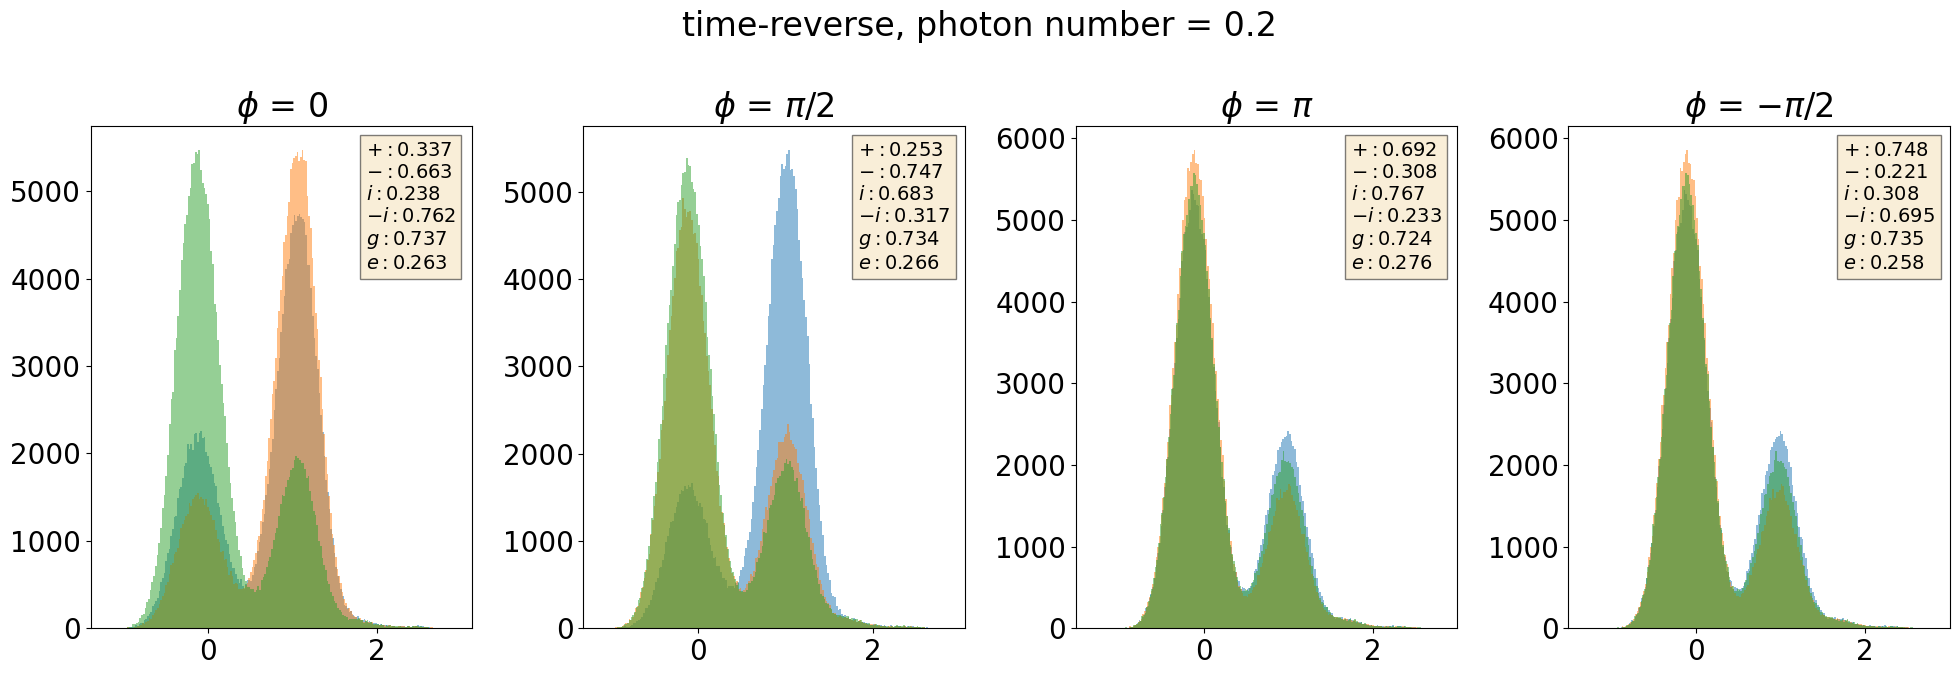

In [272]:
## tr, ph_num = 0.2
data = "/2024-01-08/2024-01-08T155333_a3eb4bd5-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data, "time-reverse, photon number = 0.2")

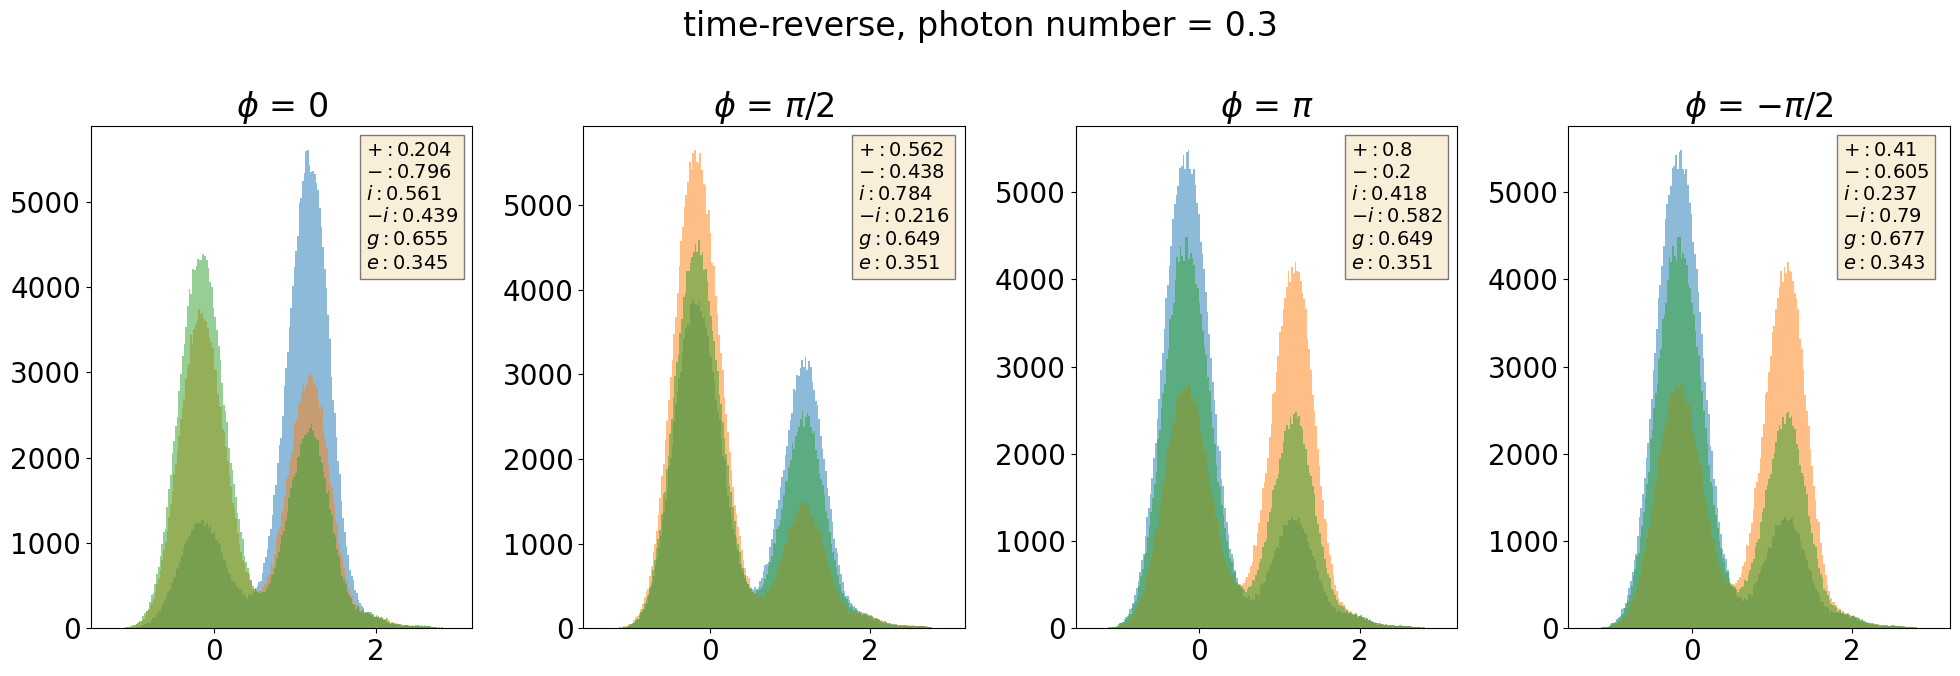

In [273]:
## tr, ph_num = 0.3
data = "/2024-01-08/2024-01-08T005916_b5af2484-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data, "time-reverse, photon number = 0.3")

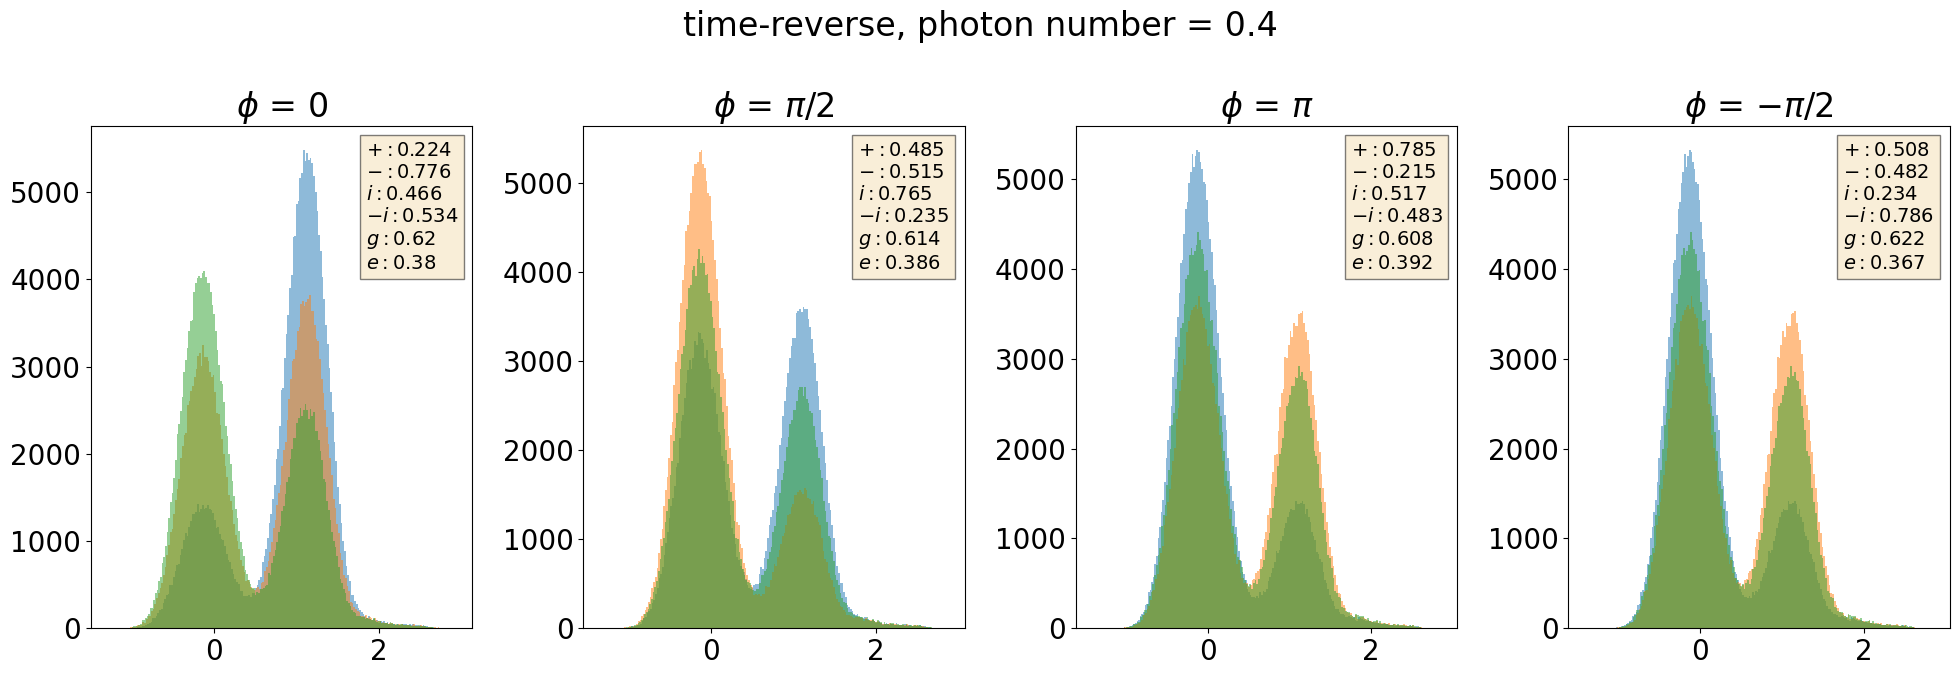

In [274]:
## tr, ph_num = 0.4
data = "/2024-01-08/2024-01-08T154559_94f1ca59-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data, "time-reverse, photon number = 0.4")

In [354]:
def fideliity(ph_phase, offset_phase, x, y, z, ph_num):
    I = 1
    X = ((2*((ph_num)**0.5*np.exp(1j*ph_phase)).real)/(1+ph_num))*(x*np.cos(offset_phase)-y*np.sin(offset_phase))
    Y = ((2*(1j*(ph_num)**0.5*np.exp(1j*ph_phase)).real)/(1+ph_num))*(x*np.sin(offset_phase)+y*np.cos(offset_phase))
    Z = (1-ph_num)/(1+ph_num)*z
    return (I + X + Y + Z)/2

0.5726551137268463

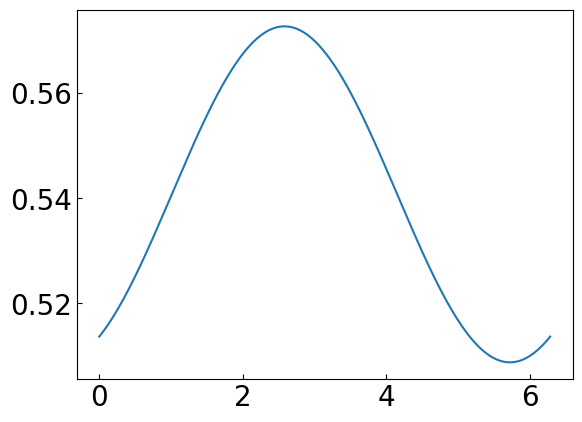

In [408]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.03
x = [0.309, 0.394, 0.643, 0.594]#[1, 0.5, 0, 0.5]#
y = [0.406,0.647, 0.61, 0.338]#[1-0.406,1- 0.647, 1-0.61, 1-0.338]#[0.5, 0, 0.5, 1]#
z =[0.099, 0.093, 0.092, 0.062]#[1-np.exp(-0.03), 1-np.exp(-0.03), 1-np.exp(-0.03), 1-np.exp(-0.03)]#
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
plt.plot(offset_phase, F)
np.max(F)

In [409]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.1
x = [0.4, 0.772, 0.601, 0.264]
y = [0.775, 0.587, 0.22, 0.413]
z =[0.173, 0.182, 0.182, 0.212]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.6576145273269738

In [411]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.2
x = [0.337, 0.253, 0.692, 0.748]
y = [0.238, 0.683, 0.767, 0.308]
z =[0.263, 0.266, 0.276, 0.258]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.705823621428274

In [358]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.3
x = [0.204, 0.562, 0.8, 0.41]
y = [0.561, 0.784, 0.418, 0.237]
z =[0.345, 0.351, 0.351, 0.343]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.717896408110396

In [395]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.4
x = [0.224, 0.485, 0.785, 0.508]
y =[0.466, 0.765, 0.517, 0.234]
z =[0.38, 0.386, 0.392, 0.367]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.7053079761047075

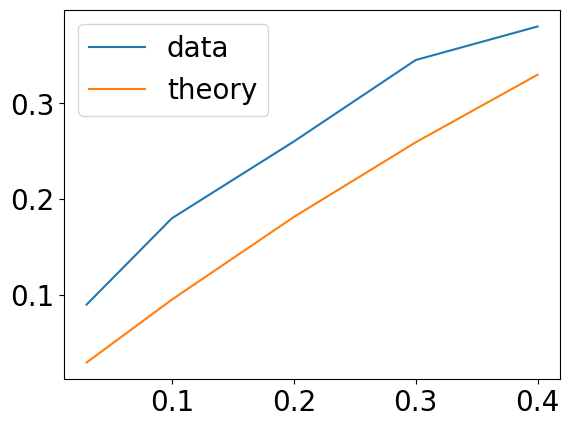

In [294]:
n = np.array([0.03, 0.1 ,0.2, 0.3, 0.4])
P_e = [0.09, 0.18, 0.26, 0.345, 0.38]
plt.plot(n, P_e, label = "data")
plt.plot(n, 1-np.exp(-n), label = "theory")
plt.legend()

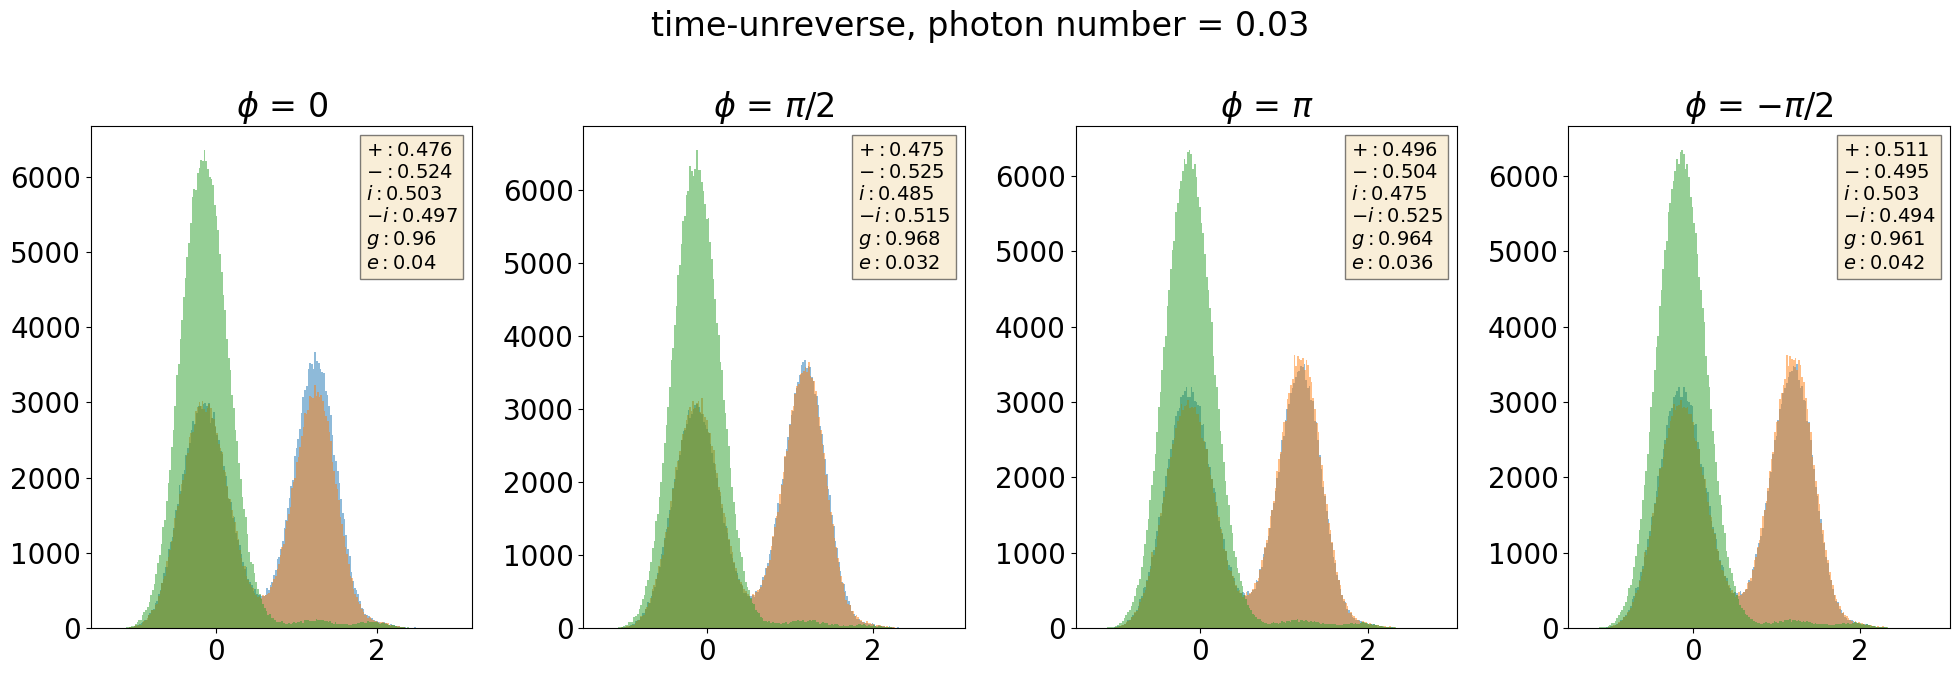

In [279]:
## utr, ph_num 0.03
data = "/2024-01-08/2024-01-08T163539_859108b2-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data, "time-unreverse, photon number = 0.03")

In [360]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.03
x = [0.476, 0.475, 0.496, 0.511]
y = [0.497, 0.515, 0.525, 0.494]
z =[0.04, 0.032, 0.036, 0.042]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.5208530822601037

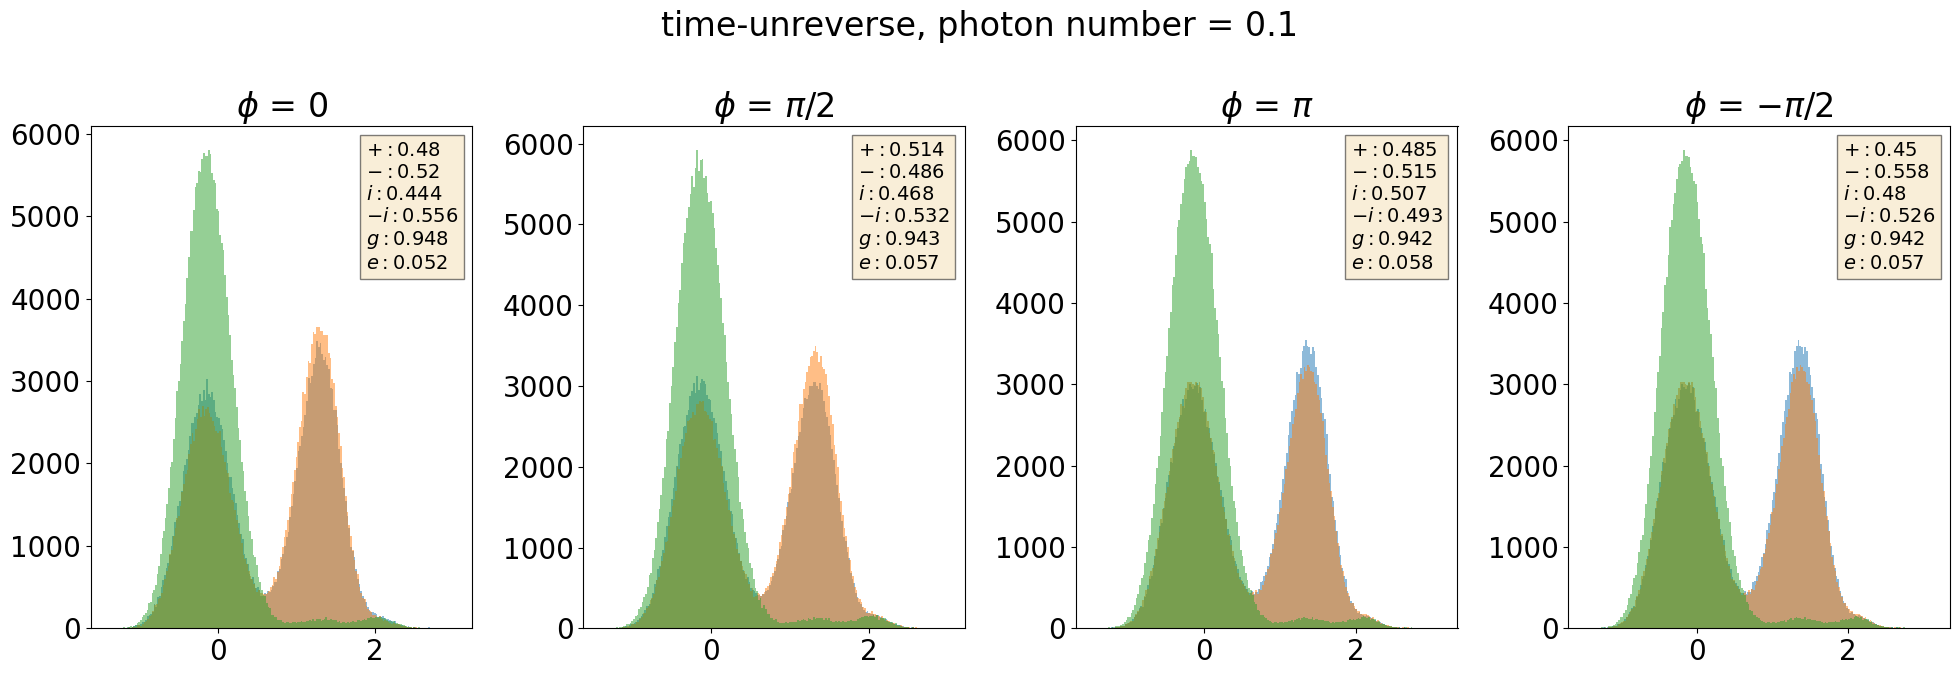

In [281]:
## utr, ph_num = 0.1
data = "/2024-01-08/2024-01-08T162749_6d3bcba7-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data,"time-unreverse, photon number = 0.1")

In [361]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.1
x = [0.48, 0.514, 0.485, 0.45]
y = [0.556, 0.532, 0.493, 0.526]
z =[0.052, 0.057, 0.058, 0.057]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.5320707362067841

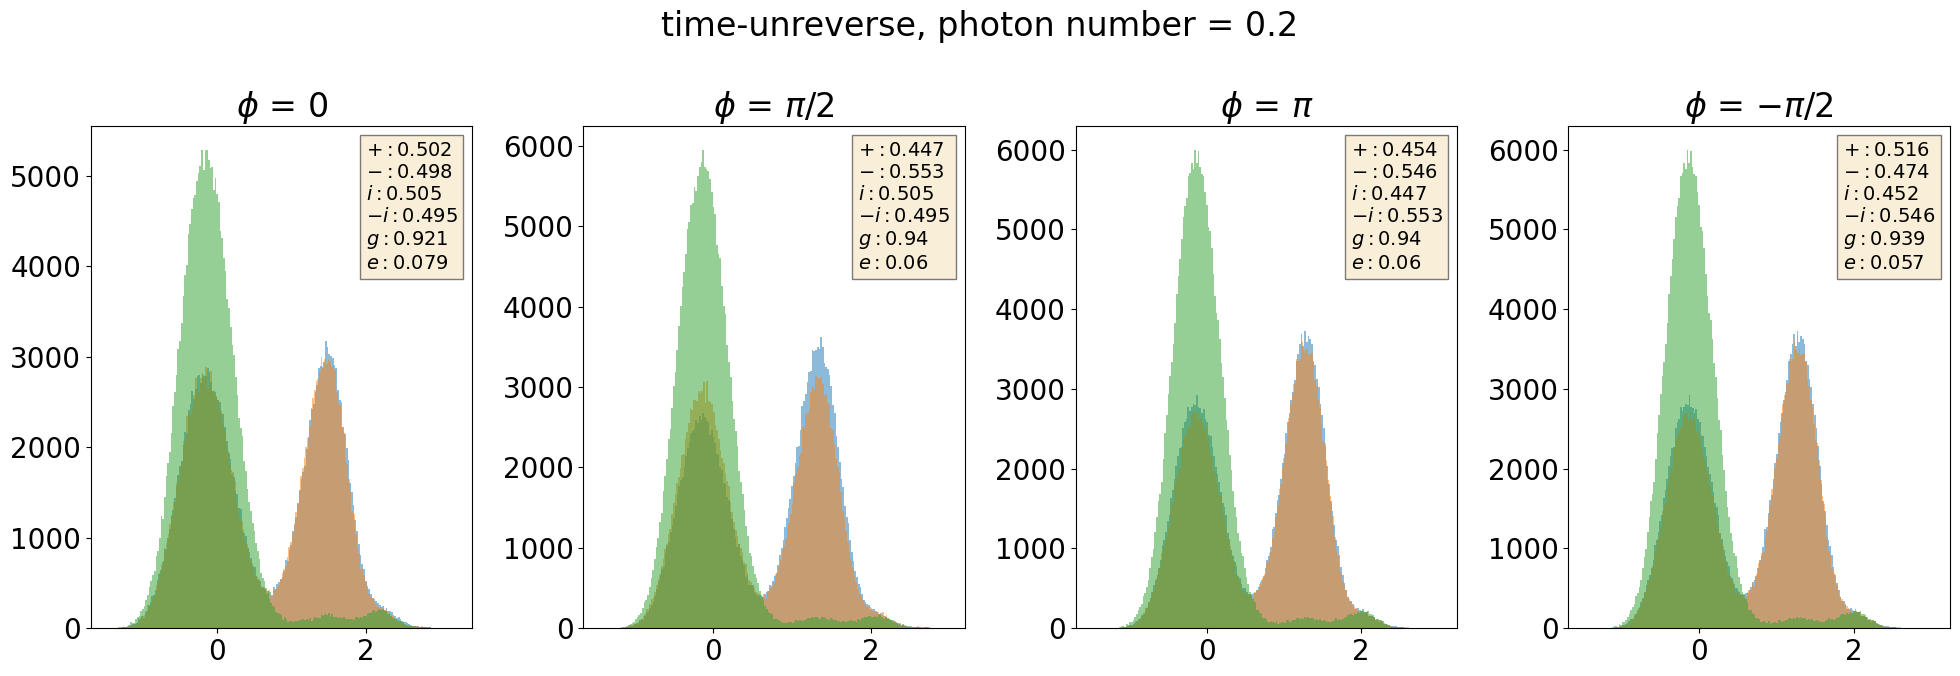

In [282]:
## utr, ph_num = 0.2
data = "/2024-01-08/2024-01-08T162106_7d25c21a-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data, "time-unreverse, photon number = 0.2")

In [362]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.2
x = [0.502, 0.447, 0.454, 0.516]
y = [0.495, 0.495, 0.553, 0.546]
z =[0.079, 0.06, 0.06, 0.057]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.5363361834352086

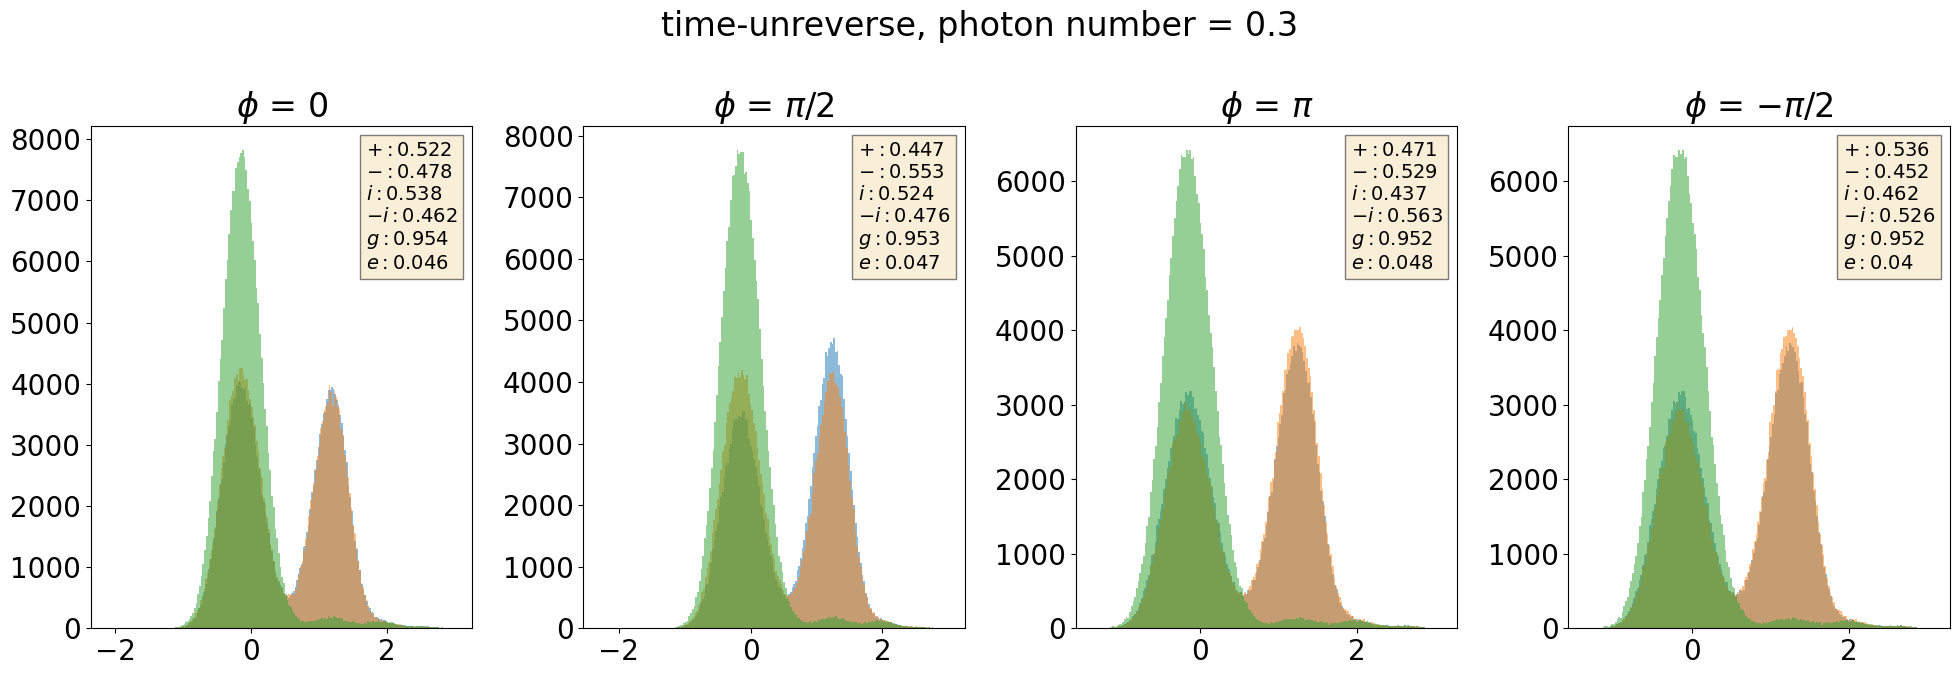

In [283]:
## utr, ph_num = 0.3
data ="/2024-01-08/2024-01-08T101638_92a1af14-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data, "time-unreverse, photon number = 0.3")

In [363]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.3
x = [0.522, 0.447, 0.471, 0.536]
y = [0.462, 0.476, 0.563, 0.526]
z =[0.046, 0.047, 0.048, 0.04]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.5348474970477457

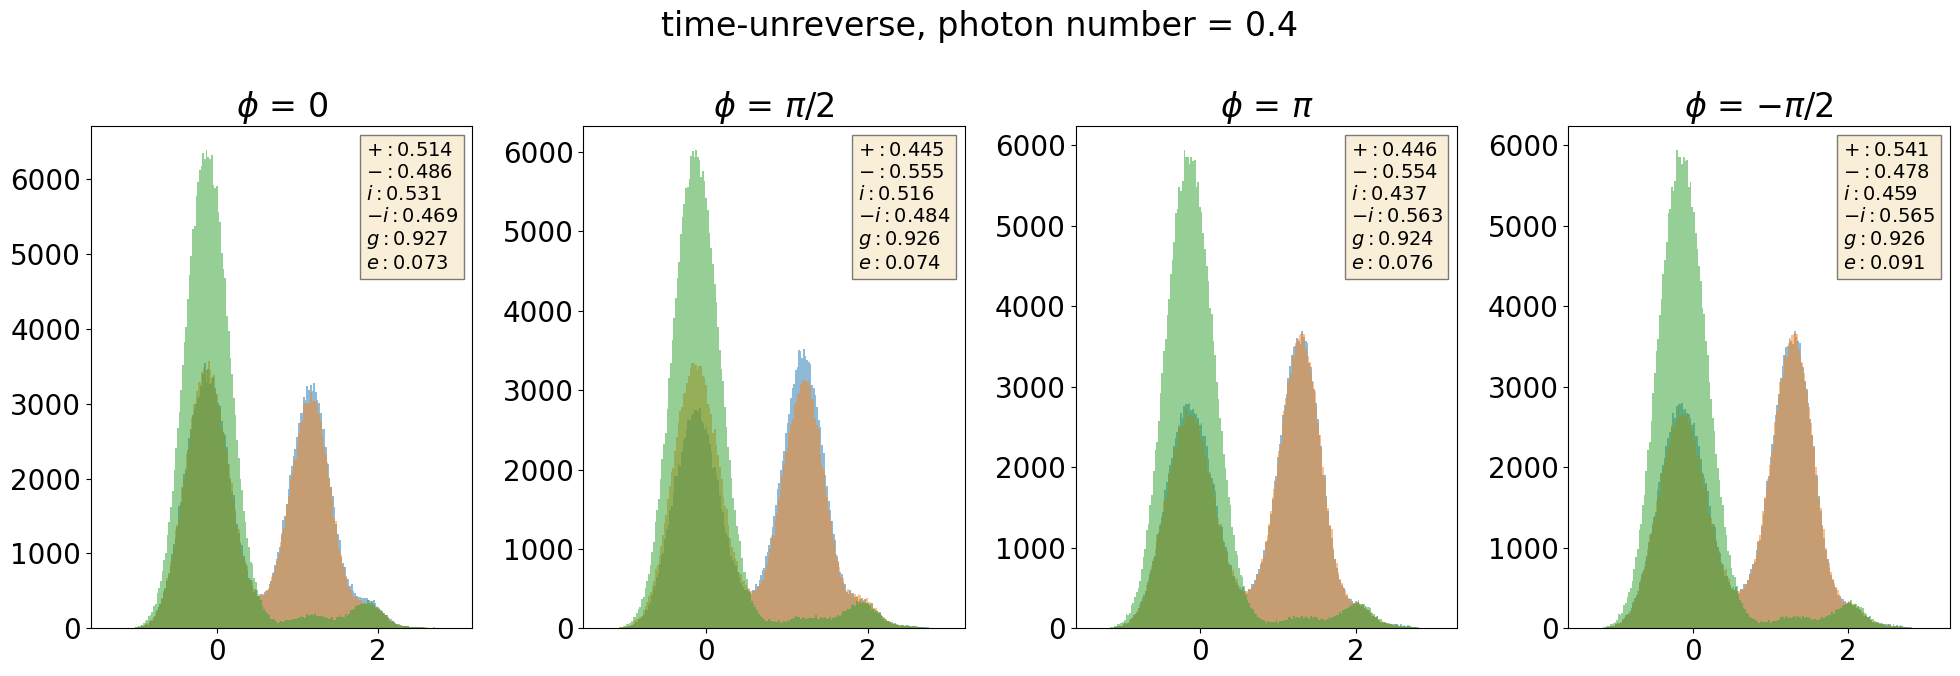

In [284]:
## utr, ph_num = 0.4
data = "/2024-01-08/2024-01-08T161332_6e778190-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data, "time-unreverse, photon number = 0.4")

In [364]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.4
x = [0.514, 0.445, 0.446, 0.541]
y = [0.469, 0.484, 0.563, 0.565]
z =[0.073, 0.074, 0.076, 0.091]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.5440910910475973

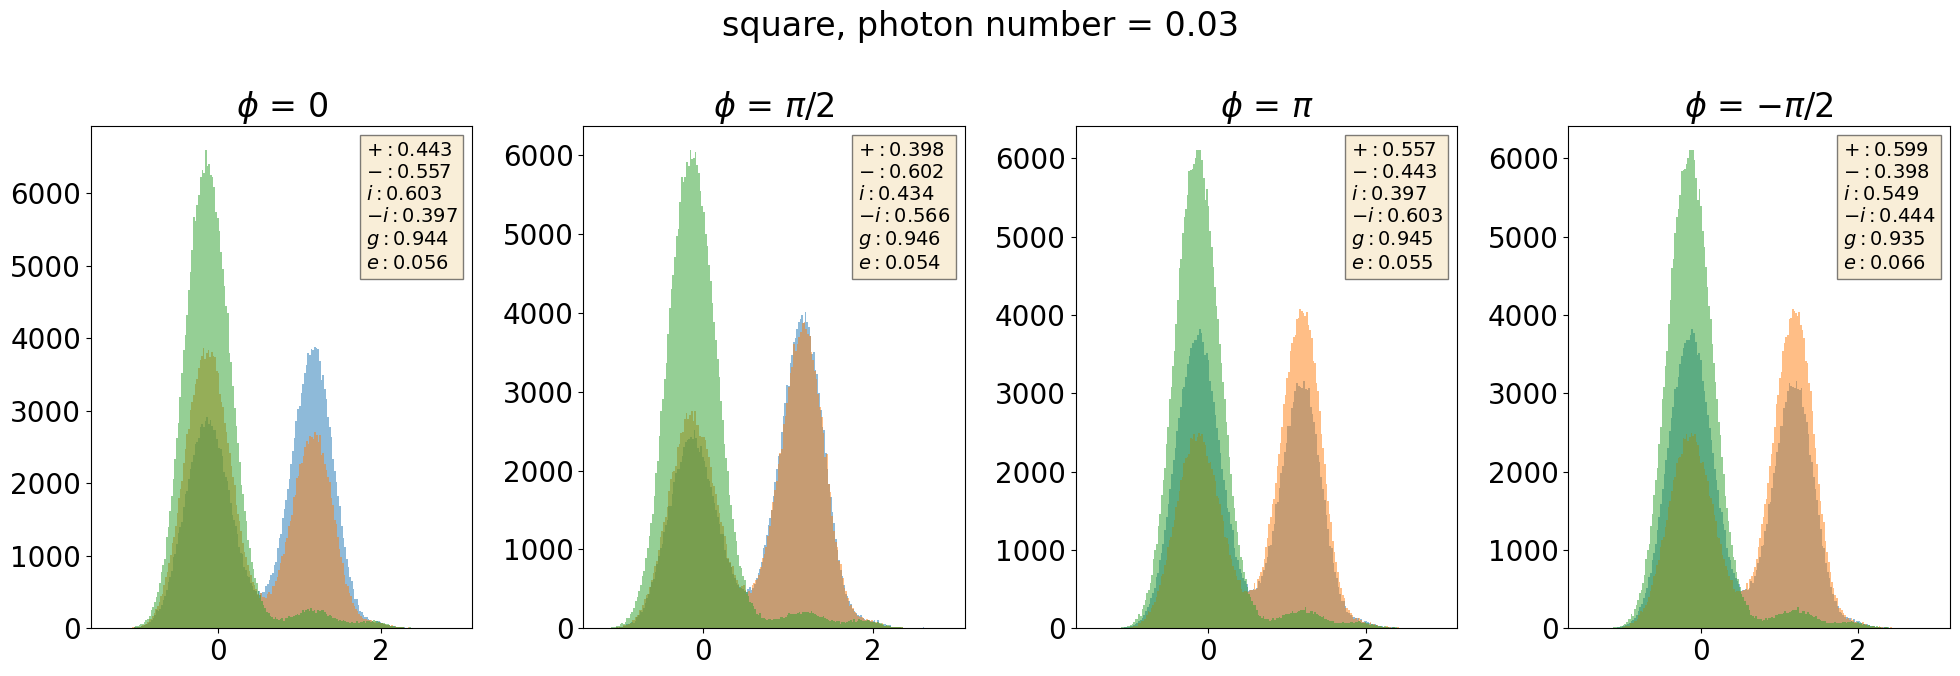

In [285]:
## sq, ph_num 0.03
data = "/2024-01-08/2024-01-08T164925_716b51da-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data,"square, photon number = 0.03")

In [365]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.03
x = [0.443, 0.398, 0.557, 0.599]
y = [0.397, 0.566, 0.603, 0.444]
z =[0.056, 0.054, 0.055, 0.066]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.5469716321696615

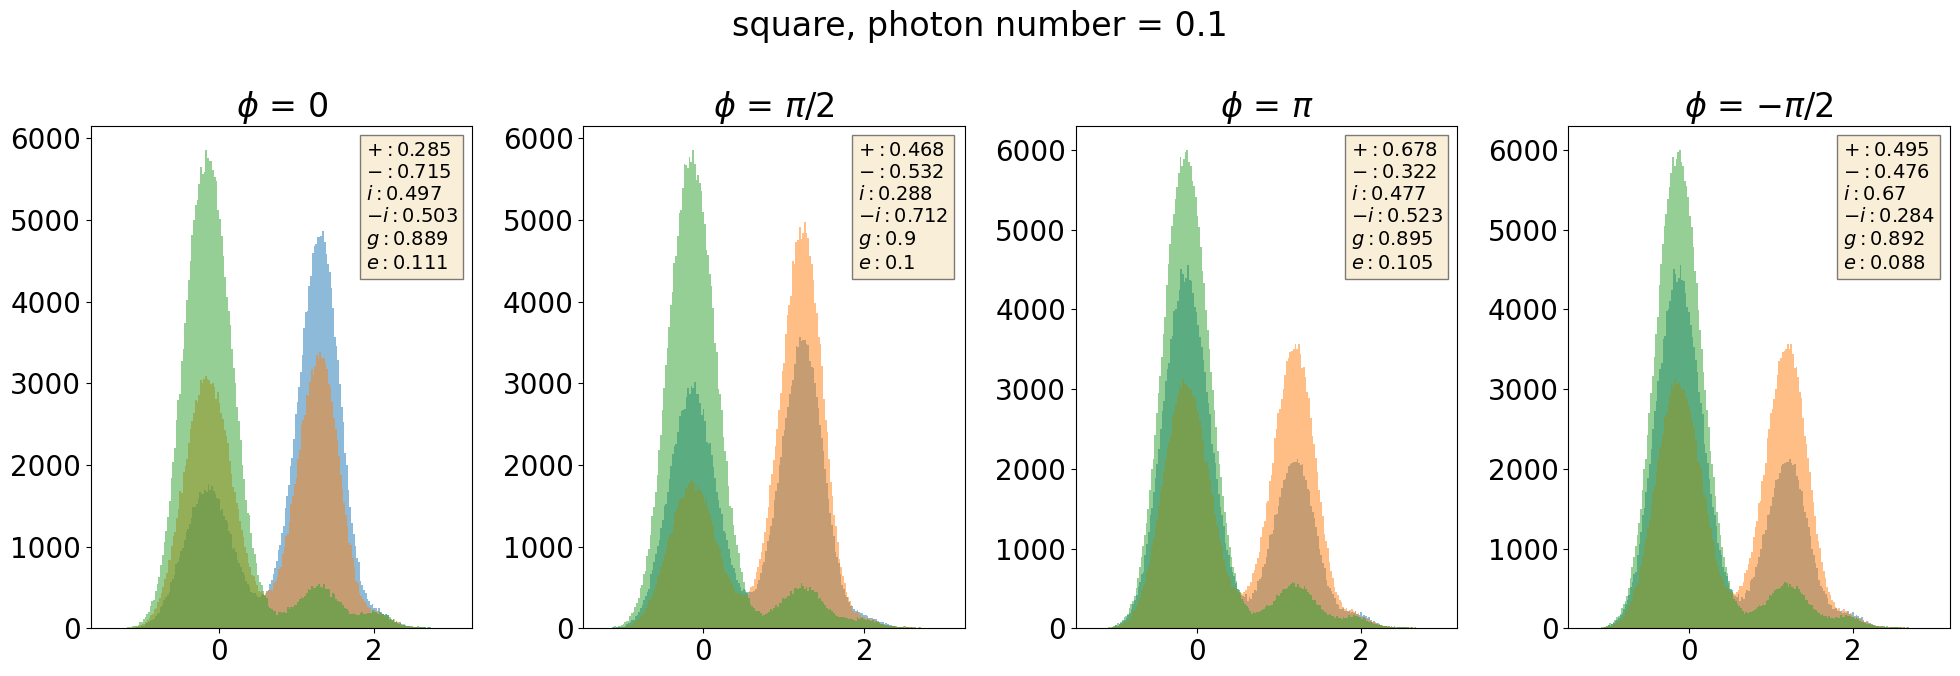

In [286]:
## sq, ph_num = 0.1
data = "/2024-01-08/2024-01-08T165612_64629f76-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data,"square, photon number = 0.1")

In [366]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.1
x = [0.285, 0.468, 0.678, 0.495]
y = [0.503, 0.712, 0.523, 0.284]
z =[0.111, 0.1, 0.105, 0.088]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.6004200045126175

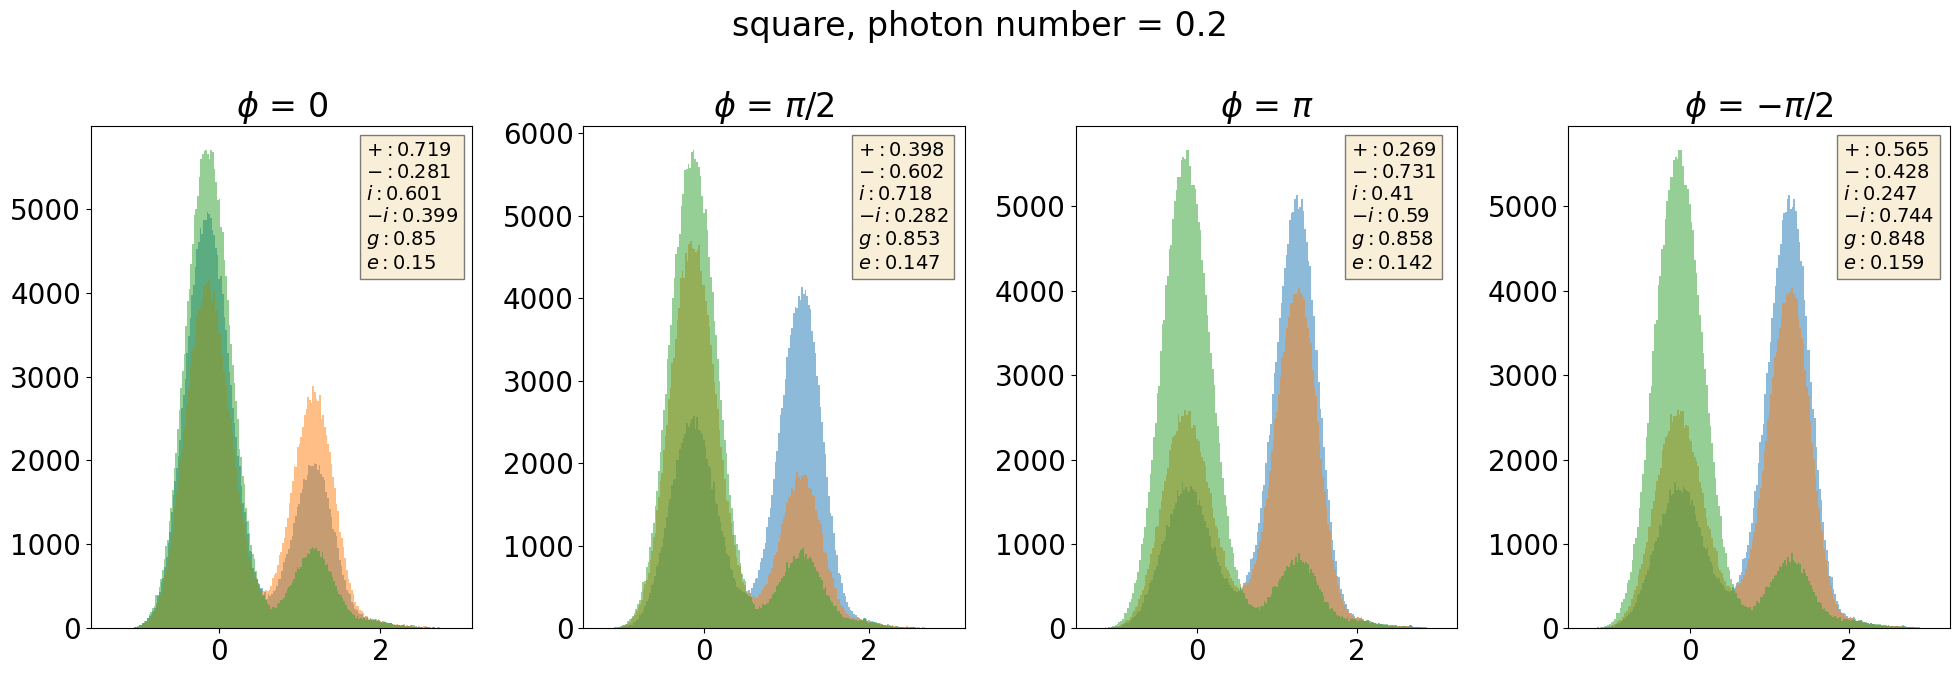

In [289]:
## sq, ph_num = 0.2
data = "/2024-01-08/2024-01-08T171329_ce75bb59-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data,"square, photon number = 0.2")

In [367]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.2
x = [0.719, 0.398, 0.269, 0.565]
y = [0.399, 0.282, 0.59, 0.744]
z =[0.15, 0.147, 0.142, 0.159]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.6411156604332716

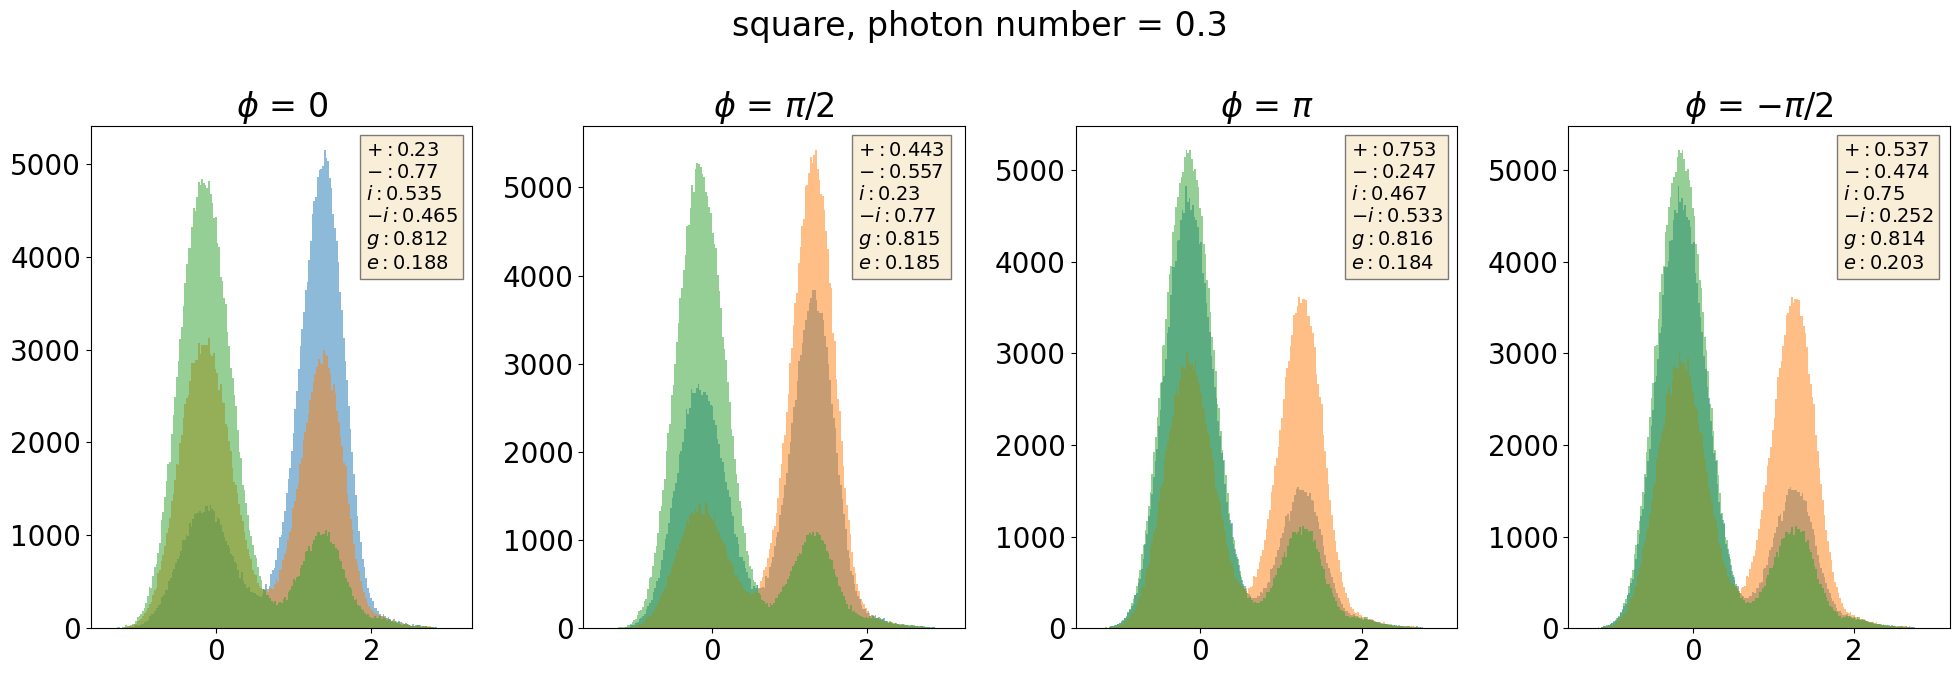

In [290]:
## sq, ph_num = 0.3
data = "/2024-01-08/2024-01-08T172044_d17b5502-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data,"square, photon number = 0.3")

In [407]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.3
x = [0.23, 0.443, 0.753, 0.537]
y =[0.465, 0.77, 0.533, 0.252]
z =[0.188, 0.185, 0.184, 0.203]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.6621230625931225

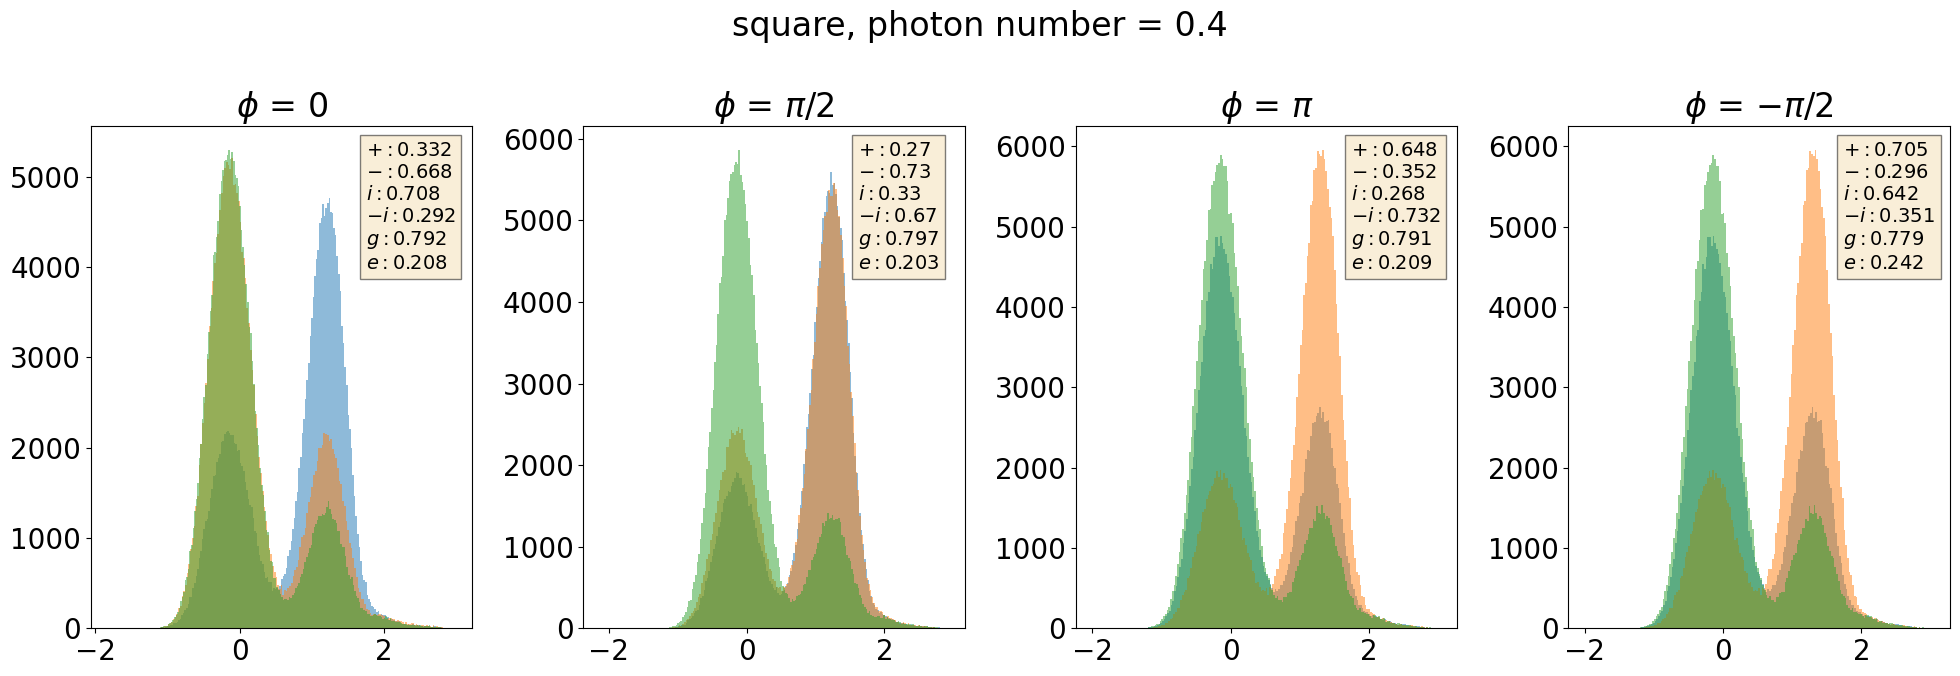

In [291]:
## sq, ph_num = 0.4
data = "/2024-01-08/2024-01-08T172711_b845264a-86_absoption_tomography"
dd = datadict_from_hdf5(header + data +"/data")
tomography(data,"square, photon number = 0.4")

In [369]:
offset_phase = np.linspace(0, 2*np.pi, 1001)
ph_num = 0.4
x = [0.332, 0.27, 0.648, 0.705]
y = [0.292, 0.67, 0.732, 0.351]
z =[0.208, 0.203, 0.209, 0.242]
F = (fideliity(0, offset_phase, x[0], y[0], z[0], ph_num) +fideliity(np.pi/2, offset_phase, x[1], y[1], z[1], ph_num) +fideliity(np.pi, offset_phase, x[2], y[2], z[2], ph_num) +fideliity(-np.pi/2, offset_phase, x[3], y[3], z[3], ph_num) )/4
# plt.plot(offset_phase, F)
np.max(F)

0.6682801546935175

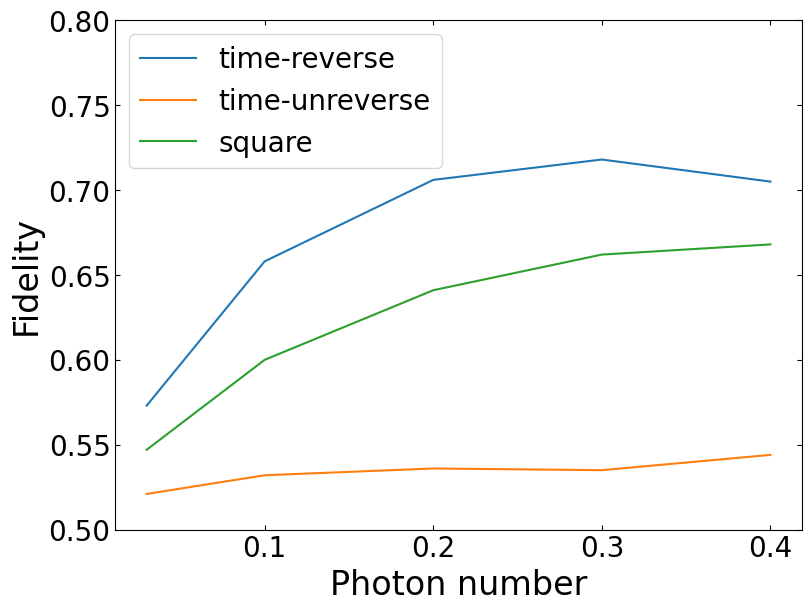

In [375]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

F_tr = [0.573, 0.658, 0.706, 0.718, 0.705]
F_utr = [0.521, 0.532, 0.536, 0.535, 0.544]
F_sq = [0.547, 0.600, 0.641, 0.662, 0.668]
ph_num = [0.03, 0.1, 0.2, 0.3, 0.4]
plt.title("")
plt.legend("")
ax.set_xlabel('Photon number', size='large')
ax.set_ylabel('Fidelity', size='large')
plt.plot(ph_num, F_tr, label = "time-reverse")
plt.plot(ph_num, F_utr, label = "time-unreverse")
plt.plot(ph_num, F_sq, label = "square")
plt.ylim(0.5, 0.8)
plt.legend()